# 🦷 Dental Caries Detection (ICDAS **D1–D6**) — RF-DETR-2XL on a single RTX PRO 6000 (96 GB)

**Self-contained:** import → *Run All*. Downloads from Roboflow (COCO format), cleans the data,
trains **RF-DETR-2XL**, evaluates on the held-out test split, and saves the model + test
predictions + all graphs.

### Design decisions (the "why")
- **D0 (healthy) is dropped.** EDA shows D0 is annotated in only a small minority of images while
  most images contain caries — so healthy teeth are *background* in most images and a *D0 box* in a
  few. That contradictory signal hurts every class. We train **D1–D6** only (6 classes).
- **One straight multiclass RF-DETR-2XL** — the largest, most accurate RF-DETR (DINOv2 backbone,
  ~127M params, native ~880px). Your priority — *"detecting the caries but wrong grade beats
  missing it"* — is a localization-recall goal the multiclass model already learns; we expose it at
  **evaluation** via a class-agnostic **caries-presence** Precision/Recall sweep, not a 2nd model.
- **Resolution is the top lever** for these small lesions (median lesion is tiny) → `RESOLUTION=880`,
  the **2XL native resolution** (we follow the model default rather than forcing a custom value).

### Recipe (RF-DETR defaults / documented best practice)
`RFDETR2XLarge` · `resolution=880` (2XL native) · `epochs=100` · `batch_size=16 × grad_accum=1`
(official rule: keep the product == 16; powerful-GPU setting) · `lr=1e-4` (default) · fine-tune from
the COCO-pretrained 2XL checkpoint · EMA + best-checkpointing (on by default) ·
`optimize_for_inference()` before eval.

### Outputs (saved under `WORK/`)
`best.pth` · `test_metrics.json` · `caries_presence.json` · annotated `predictions_test/` ·
`plots/` (training curve, caries-presence) · per-class mAP.

> **License note:** RF-DETR-XL/2XL ship under **PML 1.0** (the `rfdetr_plus` extension), not Apache.

## 1 · Environment
The Vast.ai PyTorch image already ships torch/CUDA — we only add the extras. RF-DETR-2XL needs
the **Plus** extension plus the **train/loggers** extras (COCO evaluator, faster_coco_eval, …).

In [1]:
!nvidia-smi

Mon Jun 29 03:17:50 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 590.48.01              Driver Version: 590.48.01      CUDA Version: 13.1     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA RTX PRO 6000 Blac...    On  |   00000000:01:00.0 Off |                  Off |
| 43%   33C    P8             24W /  600W |       1MiB /  97887MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
import sys
# Fresh env: install into THIS kernel's interpreter via {sys.executable} (a bare `!pip`
# can target a different Python than the running kernel). torch/CUDA already ship in the
# Vast.ai PyTorch image, so we don't reinstall them.
#   - rfdetr[plus]          -> unlocks RFDETR-XL / RFDETR-2XL (PML 1.0 weights)
#   - rfdetr[train,loggers] -> COCO evaluator + training deps (else .train() errors)
#   - supervision           -> shared metrics / annotators
!{sys.executable} -m pip install --upgrade pip
!{sys.executable} -m pip install "rfdetr[plus,train,loggers]>=1.4.0" supervision roboflow \
    opencv-python-headless pandas matplotlib pyyaml pycocotools faster_coco_eval

  Using cached filetype-1.2.0-py2.py3-none-any.whl.metadata (6.5 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 29.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 103.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 87.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 118.5 MB/s  0:00:00m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 58.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 61.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 98.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 588.1/588.1 kB 17.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 84.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 48.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.9/72.9 MB 120.0 MB/s  0:00:00m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 801.3/801.3 kB 30.4 MB/s  0:00:0

In [3]:
import os, json, glob, random, shutil, gc, time, datetime
from collections import Counter, defaultdict
from pathlib import Path

import numpy as np
import cv2
import pandas as pd
import matplotlib.pyplot as plt
import torch
from tqdm.auto import tqdm

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

print("Torch:", torch.__version__, "| CUDA:", torch.cuda.is_available(),
      "| #GPUs:", torch.cuda.device_count())
for i in range(torch.cuda.device_count()):
    print("  GPU", i, torch.cuda.get_device_name(i),
          f"{torch.cuda.get_device_properties(i).total_memory/1024**3:.0f} GB")

Torch: 2.12.0+cu130 | CUDA: True | #GPUs: 1
  GPU 0 NVIDIA RTX PRO 6000 Blackwell Workstation Edition 95 GB


## 2 · Configuration — edit this one cell

In [4]:
# ---- Roboflow source (same project/version as the original export) ----------
ROBOFLOW_API_KEY    = "CYbAZJM8QnnIZ2ka6O5z"
ROBOFLOW_WORKSPACE  = "research-ncd8x"
ROBOFLOW_PROJECT    = "deteksi-dini-karies-icdas"
ROBOFLOW_VERSION    = 4
ROBOFLOW_COCO_FMT   = "coco"        # RF-DETR REQUIRES COCO format

# ---- class handling ---------------------------------------------------------
RAW_CLASSES  = ['D0', 'D1', 'D2', 'D3', 'D4', 'D5', 'D6']   # as exported by Roboflow
DROP_CLASSES = ['D0']                                       # healthy -> dropped (see title)
CLASSES      = [c for c in RAW_CLASSES if c not in DROP_CLASSES]   # ['D1'..'D6']
NUM_CLASSES  = len(CLASSES)                                 # 6 real grades
# RF-DETR counts categories INCLUDING the Roboflow id-0 "super" placeholder we keep in the COCO
# export, so the model's num_classes must be NUM_CLASSES + 1 (= 7). If you don't pass this, RF-DETR
# falls back to the checkpoint's 90 COCO classes and trains the wrong-size classifier head.
RFDETR_NUM_CLASSES = NUM_CLASSES + 1

# ---- training (single RTX PRO 6000, 96 GB) — RF-DETR documented defaults ------
RFDETR_RESOLUTION = 880        # 2XL native resolution (the model default)
RFDETR_EPOCHS     = 120        # RF-DETR's recommended starting value
RFDETR_LR         = 1e-4       # RF-DETR default learning rate
# Official RF-DETR rule: keep batch_size * grad_accum_steps == 16.
# Powerful-GPU setting (docs use A100 -> 16x1); the 96 GB card targets the same.
# If you hit CUDA OOM with 2XL @880, drop to 8x2, then 4x4 (the product stays 16).
RFDETR_BATCH      = 16
RFDETR_GRAD_ACCUM = 1

WORK = os.path.abspath("caries_run")
os.makedirs(WORK, exist_ok=True)
print(f"Train RFDETR-2XL @ {RFDETR_RESOLUTION}px, batch {RFDETR_BATCH} x grad_accum "
      f"{RFDETR_GRAD_ACCUM} (effective {RFDETR_BATCH*RFDETR_GRAD_ACCUM}), "
      f"{RFDETR_EPOCHS} epochs, lr {RFDETR_LR}")
print("Classes:", CLASSES, "| dropping:", DROP_CLASSES)
print("WORK =", WORK)

Train RFDETR-2XL @ 880px, batch 16 x grad_accum 1 (effective 16), 120 epochs, lr 0.0001
Classes: ['D1', 'D2', 'D3', 'D4', 'D5', 'D6'] | dropping: ['D0']
WORK = /caries_run


## 3 · Download the dataset from Roboflow (COCO format)

RF-DETR expects each split (`train`/`valid`/`test`) to contain its own `_annotations.coco.json`
plus the image files.

In [5]:
from roboflow import Roboflow
rf = Roboflow(api_key=ROBOFLOW_API_KEY)
proj = rf.workspace(ROBOFLOW_WORKSPACE).project(ROBOFLOW_PROJECT)
ds = proj.version(ROBOFLOW_VERSION).download(
    ROBOFLOW_COCO_FMT, location=os.path.join(WORK, "dataset_raw_coco"), overwrite=True)
RAW_DIR = ds.location
print("Downloaded to:", RAW_DIR)

def find_split(root, names):
    for n in names:
        p = os.path.join(root, n)
        if os.path.isdir(p):
            return p
    return None

RAW_SPLITS = {
    "train": find_split(RAW_DIR, ["train"]),
    "valid": find_split(RAW_DIR, ["valid", "val"]),
    "test":  find_split(RAW_DIR, ["test"]),
}
print("Raw splits:", {k: (os.path.basename(v) if v else None) for k, v in RAW_SPLITS.items()})
for s, d in RAW_SPLITS.items():
    j = os.path.join(d, "_annotations.coco.json") if d else None
    print(f"  {s}: {'OK' if j and os.path.exists(j) else 'MISSING'}  {j}")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to /caries_run/dataset_raw_coco in coco:: 100%|██████████| 3229/3229 [00:00<00:00, 31625.00it/s]

Downloaded to: /caries_run/dataset_raw_coco
Raw splits: {'train': 'train', 'valid': 'valid', 'test': 'test'}
  train: OK  /caries_run/dataset_raw_coco/train/_annotations.coco.json
  valid: OK  /caries_run/dataset_raw_coco/valid/_annotations.coco.json
  test: OK  /caries_run/dataset_raw_coco/test/_annotations.coco.json


## 4 · Clean the dataset — drop D0, remap D1–D6 → contiguous COCO ids

We rewrite each split's COCO json: remove every D0 annotation and renumber the remaining grades
into contiguous category ids `1..6` (id `0` is kept as the Roboflow "super" placeholder that
RF-DETR expects). Images whose annotations become **empty are KEPT as background negatives** — real
mouths with no caries, which suppress false positives (helps precision).

In [6]:
CLEAN_DIR = os.path.join(WORK, "dataset_d1d6_coco")
if os.path.exists(CLEAN_DIR):
    shutil.rmtree(CLEAN_DIR)
IMG_EXTS = (".jpg", ".jpeg", ".png", ".bmp")

# New category table: id 0 = super placeholder (Roboflow convention), D1..D6 -> 1..6
NEW_CAT_ID = {name: i + 1 for i, name in enumerate(CLASSES)}     # D1->1 ... D6->6
NEW_CATEGORIES = [{"id": 0, "name": "caries-icdas", "supercategory": "none"}]
for name in CLASSES:
    NEW_CATEGORIES.append({"id": NEW_CAT_ID[name], "name": name, "supercategory": "caries-icdas"})

def clean_coco_split(split):
    src = RAW_SPLITS[split]
    coco = json.load(open(os.path.join(src, "_annotations.coco.json")))
    id2name = {c["id"]: c["name"] for c in coco["categories"]}
    # old object-category id -> new id (only for classes we keep)
    old2new = {cid: NEW_CAT_ID[nm] for cid, nm in id2name.items() if nm in CLASSES}

    di = os.path.join(CLEAN_DIR, split); os.makedirs(di, exist_ok=True)
    # copy images (all of them — empties become background negatives)
    n_img = 0
    for im in coco["images"]:
        fn = im["file_name"]
        sp = os.path.join(src, fn)
        if os.path.exists(sp) and fn.lower().endswith(IMG_EXTS):
            shutil.copy2(sp, os.path.join(di, os.path.basename(fn))); n_img += 1

    # filter + remap annotations
    new_anns = []; cls = Counter(); box_in = len(coco["annotations"])
    for a in coco["annotations"]:
        if a["category_id"] in old2new:
            a = dict(a); a["category_id"] = old2new[a["category_id"]]
            cls[a["category_id"]] += 1; new_anns.append(a)
    box_out = len(new_anns)

    img_with_ann = {a["image_id"] for a in new_anns}
    empty_after = sum(1 for im in coco["images"] if im["id"] not in img_with_ann)

    out = {"images": coco["images"], "annotations": new_anns, "categories": NEW_CATEGORIES}
    json.dump(out, open(os.path.join(di, "_annotations.coco.json"), "w"))
    return dict(n=n_img, box_in=box_in, box_out=box_out, empty=empty_after, cls=cls)

totals = Counter()
for s in ["train", "valid", "test"]:
    r = clean_coco_split(s); totals.update(r["cls"])
    print(f"[{s:5}] images={r['n']:4d} boxes {r['box_in']}->{r['box_out']} "
          f"(D0 dropped {r['box_in']-r['box_out']}) bg_after={r['empty']} | "
          + ", ".join(f"{CLASSES[c-1]}={r['cls'].get(c,0)}" for c in range(1, NUM_CLASSES+1)))
print("TOTAL per class:", {CLASSES[c-1]: totals.get(c, 0) for c in range(1, NUM_CLASSES+1)})
print("\nCleaned COCO dataset ->", CLEAN_DIR)
SPLIT_DIRS = {s: os.path.join(CLEAN_DIR, s) for s in ["train", "valid", "test"]}

[train] images=2266 boxes 7806->6745 (D0 dropped 1061) bg_after=180 | D1=893, D2=1232, D3=1148, D4=872, D5=1242, D6=1358
[valid] images= 635 boxes 2040->1675 (D0 dropped 365) bg_after=75 | D1=247, D2=301, D3=215, D4=196, D5=307, D6=409
[test ] images= 320 boxes 1021->834 (D0 dropped 187) bg_after=38 | D1=110, D2=147, D3=147, D4=114, D5=154, D6=162
TOTAL per class: {'D1': 1250, 'D2': 1680, 'D3': 1510, 'D4': 1182, 'D5': 1703, 'D6': 1929}

Cleaned COCO dataset -> /caries_run/dataset_d1d6_coco


## 5 · EDA — justify the D0 drop, then characterise D1–D6

First we quantify the D0 problem on the **raw** download (so the decision is evidence-based),
then we analyse the **cleaned** set: class balance, background images, and object size.

In [7]:
# ---- D0 coverage on the RAW COCO data (the justification) ----
def raw_coverage(split, target="D0"):
    coco = json.load(open(os.path.join(RAW_SPLITS[split], "_annotations.coco.json")))
    id2name = {c["id"]: c["name"] for c in coco["categories"]}
    tgt_ids = {cid for cid, nm in id2name.items() if nm == target}
    car_ids = {cid for cid, nm in id2name.items() if nm in CLASSES}
    per_img = defaultdict(set)
    for a in coco["annotations"]:
        per_img[a["image_id"]].add(a["category_id"])
    n = len(coco["images"])
    with_t   = sum(1 for im in coco["images"] if per_img[im["id"]] & tgt_ids)
    with_car = sum(1 for im in coco["images"] if per_img[im["id"]] & car_ids)
    return n, with_t, with_car

print("=== D0 coverage on RAW (why we drop it) ===")
for s in ["train", "valid", "test"]:
    n, d0, car = raw_coverage(s)
    print(f"[{s:5}] images={n:4d} | with D0={d0:4d} ({100*d0/max(n,1):4.1f}%) | "
          f"with caries={car:4d} ({100*car/max(n,1):4.1f}%)")
print("-> D0 in a small minority of images but caries in most => D0 label is unreliable; drop it.")

=== D0 coverage on RAW (why we drop it) ===
[train] images=2266 | with D0= 410 (18.1%) | with caries=2086 (92.1%)
[valid] images= 635 | with D0= 148 (23.3%) | with caries= 560 (88.2%)
[test ] images= 320 | with D0=  72 (22.5%) | with caries= 282 (88.1%)
-> D0 in a small minority of images but caries in most => D0 label is unreliable; drop it.


In [8]:
# ---- cleaned-set EDA: class balance, background, object size ----
def load_clean(split):
    coco = json.load(open(os.path.join(SPLIT_DIRS[split], "_annotations.coco.json")))
    wh = {im["id"]: (im["width"], im["height"]) for im in coco["images"]}
    return coco, wh

eda = {}
for split in ["train", "valid", "test"]:
    coco, wh = load_clean(split)
    cls = Counter(); areas = []; cls_area = defaultdict(list)
    per_img = defaultdict(int)
    for a in coco["annotations"]:
        c = a["category_id"]; W, H = wh[a["image_id"]]
        bw, bh = a["bbox"][2], a["bbox"][3]
        na = (bw * bh) / (W * H + 1e-9)             # normalized area
        cls[c] += 1; areas.append(na); cls_area[c].append(na); per_img[a["image_id"]] += 1
    bpi = [per_img[im["id"]] for im in coco["images"]]
    empties = sum(1 for v in bpi if v == 0)
    eda[split] = dict(n=len(coco["images"]), cls=cls, bpi=bpi, empties=empties,
                      areas=areas, cls_area=cls_area)

grand = sum(sum(eda[s]["cls"].values()) for s in eda)
print(f"{'class':<6}" + "".join(f"{s:>9}" for s in eda) + f"{'TOTAL':>9}{'%':>7}")
for i, nm in enumerate(CLASSES):
    cid = i + 1
    tot = sum(eda[s]['cls'].get(cid, 0) for s in eda)
    print(f"{nm:<6}" + "".join(f"{eda[s]['cls'].get(cid,0):>9}" for s in eda)
          + f"{tot:>9}{100*tot/max(grand,1):>6.1f}%")
for s in eda:
    b = eda[s]['bpi']
    print(f"[{s}] images={eda[s]['n']} background={eda[s]['empties']} "
          f"boxes/img={sum(b)/max(len(b),1):.2f} (max {max(b) if b else 0})")

areas = np.array(eda['train']['areas']); R = RFDETR_RESOLUTION; ap = areas * R * R
small = np.sum(ap < 32*32); medium = np.sum((ap >= 32*32) & (ap < 96*96)); large = np.sum(ap >= 96*96)
t = max(len(areas), 1)
print(f"\nObject size @ {R}px: small {100*small/t:.1f}% | medium {100*medium/t:.1f}% | large {100*large/t:.1f}%")
print(f"median equiv side = {np.sqrt(np.median(areas))*R:.1f}px (small => resolution matters most)")
for i, nm in enumerate(CLASSES):
    a = eda['train']['cls_area'][i + 1]
    if a: print(f"  {nm}: ~{np.sqrt(np.mean(a))*R:5.1f}px  (n={len(a)})")

class     train    valid     test    TOTAL      %
D1          893      247      110     1250  13.5%
D2         1232      301      147     1680  18.2%
D3         1148      215      147     1510  16.3%
D4          872      196      114     1182  12.8%
D5         1242      307      154     1703  18.4%
D6         1358      409      162     1929  20.8%
[train] images=2266 background=180 boxes/img=2.98 (max 18)
[valid] images=635 background=75 boxes/img=2.64 (max 15)
[test] images=320 background=38 boxes/img=2.61 (max 13)

Object size @ 880px: small 21.7% | medium 58.5% | large 19.7%
median equiv side = 53.9px (small => resolution matters most)
  D1: ~ 63.9px  (n=893)
  D2: ~ 71.4px  (n=1232)
  D3: ~ 74.7px  (n=1148)
  D4: ~ 88.3px  (n=872)
  D5: ~121.2px  (n=1242)
  D6: ~135.7px  (n=1358)


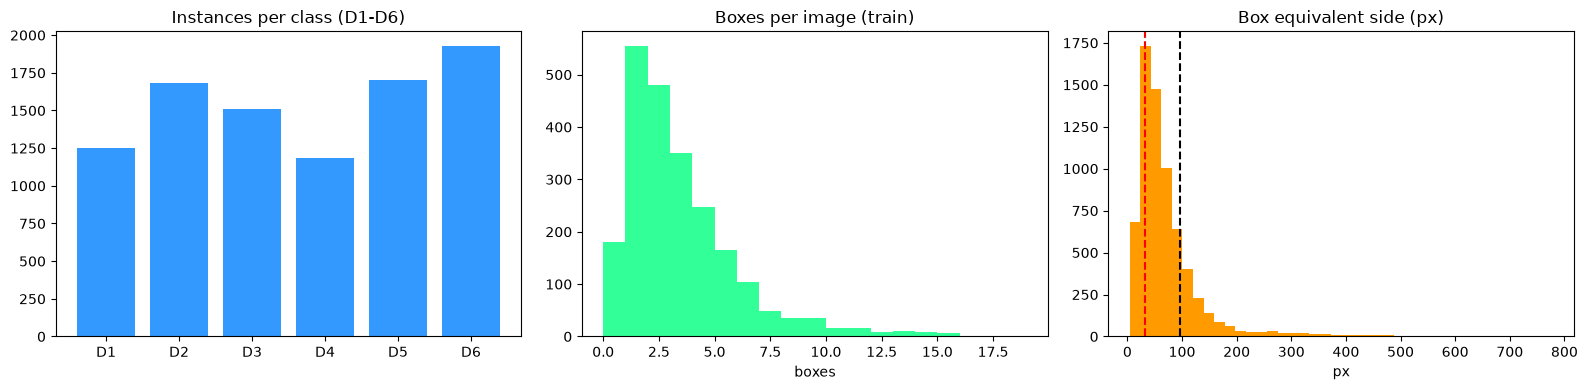

In [9]:
# ---- EDA figure ----
R = RFDETR_RESOLUTION
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
counts = [sum(eda[s]['cls'].get(i+1, 0) for s in eda) for i in range(NUM_CLASSES)]
ax[0].bar(CLASSES, counts, color="#3399ff"); ax[0].set_title("Instances per class (D1-D6)")
mx = max(eda['train']['bpi']) if eda['train']['bpi'] else 1
ax[1].hist(eda['train']['bpi'], bins=range(0, mx + 2), color="#33ff99")
ax[1].set_title("Boxes per image (train)"); ax[1].set_xlabel("boxes")
px_side = np.sqrt(np.array(eda['train']['areas'])) * R
ax[2].hist(px_side, bins=40, color="#ff9b00")
ax[2].axvline(32, color="r", ls="--"); ax[2].axvline(96, color="k", ls="--")
ax[2].set_title("Box equivalent side (px)"); ax[2].set_xlabel("px")
plt.tight_layout(); plt.savefig(os.path.join(WORK, "eda_overview.png"), dpi=110); plt.show()

## 6 · Caries-aware augmentation — verified before training

ICDAS grading depends on enamel **colour** (white-spot vs brown vs cavitation). RF-DETR applies
its own training-time augmentation (resize/scale + horizontal flip), so the photometric changes we
*sanity-check* here are deliberately **mild**, and we use **h-flip only** for geometry (intraoral
up/down is meaningful). We render the transforms with boxes drawn to confirm they behave.

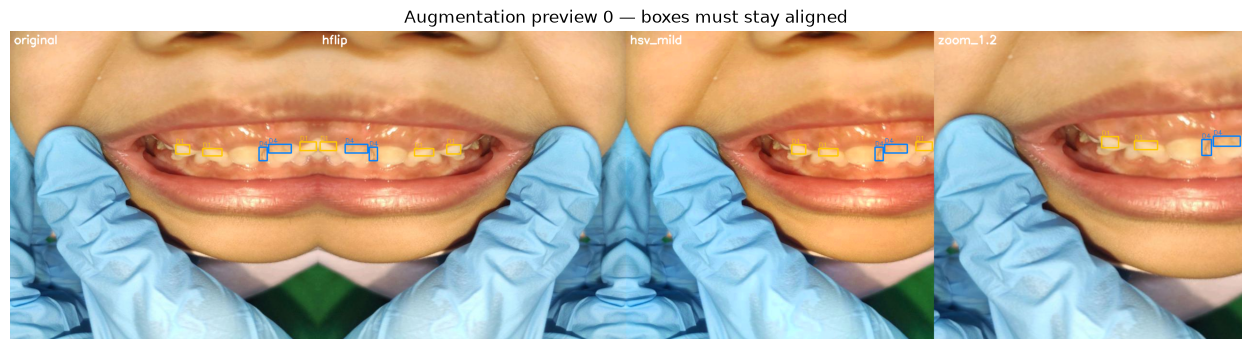

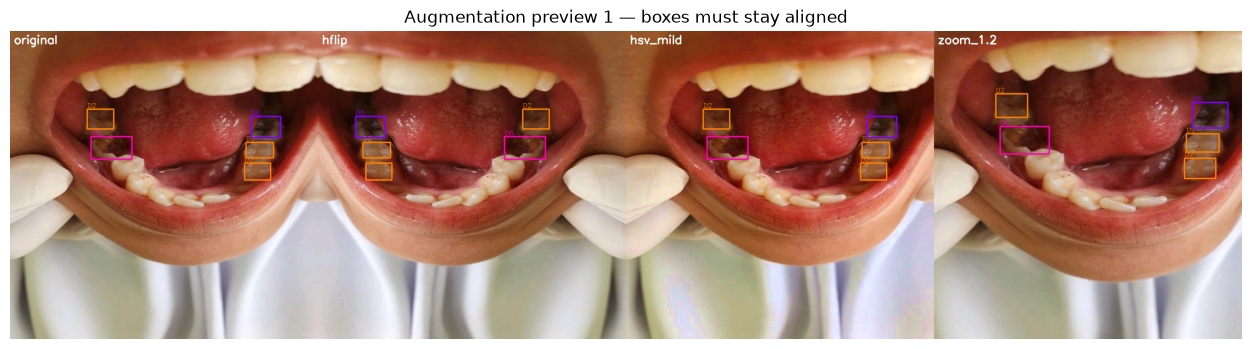

Verified: flip/zoom keep boxes aligned; mild photometric preserves grading colour cues.


In [10]:
COLORS = [(0,200,255),(0,128,255),(0,80,255),(255,128,0),(255,0,128),(180,0,255)]

def coco_index(split):
    coco = json.load(open(os.path.join(SPLIT_DIRS[split], "_annotations.coco.json")))
    by_img = defaultdict(list)
    fn = {im["id"]: im["file_name"] for im in coco["images"]}
    for a in coco["annotations"]:
        by_img[a["image_id"]].append(a)
    return coco, fn, by_img

def read_sample(split, image_id, fn, by_img):
    img = cv2.imread(os.path.join(SPLIT_DIRS[split], os.path.basename(fn[image_id])))
    boxes = []   # pixel xyxy + class index (0-based for CLASSES)
    for a in by_img[image_id]:
        x, y, w, h = a["bbox"]
        boxes.append([a["category_id"] - 1, x, y, x + w, y + h])
    return img, boxes

def draw(img, boxes):
    im = img.copy()
    for c, x1, y1, x2, y2 in boxes:
        cv2.rectangle(im, (int(x1),int(y1)), (int(x2),int(y2)), COLORS[c % len(COLORS)], 2)
        cv2.putText(im, CLASSES[c], (int(x1), max(int(y1)-3,10)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.45, COLORS[c % len(COLORS)], 1)
    return im

def t_hflip(img, b):
    w = img.shape[1]
    return img[:, ::-1].copy(), [[c, w-x2, y1, w-x1, y2] for c,x1,y1,x2,y2 in b]
def t_hsv_mild(img, b):
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV).astype(np.int16)
    hsv[...,1] = np.clip(hsv[...,1]+15, 0, 255); hsv[...,2] = np.clip(hsv[...,2]+10, 0, 255)
    return cv2.cvtColor(hsv.astype(np.uint8), cv2.COLOR_HSV2BGR), b
def t_zoom(img, b, s=1.2):
    h,w = img.shape[:2]; big = cv2.resize(img,(int(w*s),int(h*s))); H,W = big.shape[:2]
    x0,y0 = (W-w)//2,(H-h)//2; crop = big[y0:y0+h, x0:x0+w]; nb=[]
    for c,x1,y1,x2,y2 in b:
        nx1,ny1,nx2,ny2 = x1*s-x0, y1*s-y0, x2*s-x0, y2*s-y0
        if nx2>0 and ny2>0 and nx1<w and ny1<h:
            nb.append([c, max(nx1,0),max(ny1,0),min(nx2,w),min(ny2,h)])
    return crop, nb

coco, fn, by_img = coco_index("train")
multi = [im["id"] for im in coco["images"] if len(by_img[im["id"]]) >= 4][:2]
pipeline = [("original", None), ("hflip", t_hflip), ("hsv_mild", t_hsv_mild), ("zoom_1.2", t_zoom)]
for k, iid in enumerate(multi):
    img, boxes = read_sample("train", iid, fn, by_img); tiles = []
    for name, f in pipeline:
        im, bs = (img, boxes) if f is None else f(img.copy(), [b[:] for b in boxes])
        vis = draw(im, bs); cv2.putText(vis, name, (8,26), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255,255,255), 2)
        tiles.append(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
    plt.figure(figsize=(18, 4)); plt.imshow(np.hstack(tiles)); plt.axis("off")
    plt.title(f"Augmentation preview {k} — boxes must stay aligned"); plt.show()
print("Verified: flip/zoom keep boxes aligned; mild photometric preserves grading colour cues.")

## 7 · Train RF-DETR-2XL (per-epoch heartbeat)

RF-DETR-2XL uses a DINOv2 backbone and fine-tunes from the COCO-pretrained 2XL checkpoint on our
cleaned COCO export. We follow the documented defaults: `epochs=100`, `lr=1e-4`, and the official
rule `batch_size × grad_accum_steps == 16` (here **16 × 1**, the powerful-GPU setting). EMA and
best-model checkpointing are on by default. A per-epoch callback prints one flushed line
(time/epoch + loss + mAP) so you can see it's moving.

> If you hit CUDA OOM with 2XL @880: set `RFDETR_BATCH=8, RFDETR_GRAD_ACCUM=2` (then `4`/`4`) —
> the product stays 16, which is what the docs care about.

In [11]:
from rfdetr import RFDETR2XLarge
import rfdetr
print("rfdetr", getattr(rfdetr, "__version__", "?"))

rfdetr_out = os.path.join(WORK, "rfdetr_out")
os.makedirs(rfdetr_out, exist_ok=True)

rf_model = RFDETR2XLarge(resolution=RFDETR_RESOLUTION, num_classes=RFDETR_NUM_CLASSES)

# ---- per-epoch heartbeat (Lightning's live bar often doesn't stream in cloud logs) ----
_hb = {"i": 0, "t0": time.time(), "tprev": time.time()}
def _epoch_heartbeat(data: dict):
    now = time.time(); dt = now - _hb["tprev"]; _hb["tprev"] = now; _hb["i"] += 1
    ep = data.get("epoch", _hb["i"])
    msg = (f"[{datetime.datetime.now():%H:%M:%S}] epoch {ep}/{RFDETR_EPOCHS} "
           f"| {dt/60:.1f} min/epoch | elapsed {(now-_hb['t0'])/60:.1f} min")
    if isinstance(data.get("train_loss"), (int, float)):
        msg += f" | train_loss={data['train_loss']:.4f}"
    ce = data.get("test_coco_eval_bbox")
    if isinstance(ce, (list, tuple)) and len(ce) >= 2:
        msg += f" | mAP50:95={ce[0]:.4f} mAP50={ce[1]:.4f}"
    avg = (now - _hb["t0"]) / max(_hb["i"], 1)
    msg += f" | ETA {(RFDETR_EPOCHS - _hb['i']) * avg / 60:.0f} min"
    print(msg, flush=True)

# ---- storage guard: delete the periodic checkpoint_<N>.ckpt files RF-DETR drops every few epochs
#      (~1.9 GB EACH for 2XL) — they filled the disk and killed the previous run at epoch 72.
#      We KEEP last.ckpt (for resume) and the .pth best checkpoints (for eval) untouched. ----
def _prune_periodic_ckpts(_data=None):
    for p in glob.glob(os.path.join(rfdetr_out, "checkpoint_*.ckpt")):
        b = os.path.basename(p)
        if b[11:-5].isdigit():          # 'checkpoint_<N>.ckpt' only
            try: os.remove(p)
            except OSError: pass

try:
    rf_model.callbacks["on_fit_epoch_end"].append(_epoch_heartbeat)
    rf_model.callbacks["on_fit_epoch_end"].append(_prune_periodic_ckpts)
    print("Registered per-epoch heartbeat + periodic-ckpt prune callbacks.")
except Exception as e:
    print("Could not register callbacks (version mismatch):", e)

rf_model.train(
    dataset_dir=CLEAN_DIR,
    epochs=RFDETR_EPOCHS,
    batch_size=RFDETR_BATCH,
    grad_accum_steps=RFDETR_GRAD_ACCUM,
    lr=RFDETR_LR,
    output_dir=rfdetr_out,
)
print("RF-DETR training finished. Checkpoints in:", rfdetr_out)
!ls -la {rfdetr_out}

rfdetr ?
[2026-06-28 14:25:24] [INFO] rf-detr - Downloading pretrained weights for /root/.roboflow/models/rf-detr-xxlarge.pth


target=True is deprecated since `v0.8`; use `TargetMode.ARGS_REMAP` instead. Will be removed in `v1.0`.


/root/.roboflow/models/rf-detr-xxlarge.pth:   0%|          | 0.00/484M [00:00<?, ?iB/s]

[2026-06-28 14:25:32] [INFO] rf-detr - MD5 validation successful for /root/.roboflow/models/rf-detr-xxlarge.pth


[2026-06-28 14:25:32] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-06-28 14:25:32] [WARNING] rf-detr - Using patch size 20 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.


...

Trainable params: 126 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 126 M                                                                                                
Total estimated model params size (MB): 505.228                                                                    
Modules in train mode: 500                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

[2026-06-28 14:26:00] [INFO] rf-detr - Best EMA mAP improved to 0.0011 (epoch 0)
[2026-06-28 14:29:29] [INFO] rf-detr - Best regular checkpoint saved to /caries_run/rfdetr_out/checkpoint_best_regular.pth (epoch 0, monitor=val/mAP_50_95, value=0.068573)
[2026-06-28 14:29:30] [INFO] rf-detr - Best EMA mAP improved to 0.0693 (epoch 0)
[2026-06-28 14:36:13] [INFO] rf-detr - Best regular checkpoint saved to /caries_run/rfdetr_out/checkpoint_best_regular.pth (epoch 2, monitor=val/mAP_50_95, value=0.128285)
[2026-06-28 14:36:14] [INFO] rf-detr - Best EMA mAP improved to 0.1251 (epoch 2)
[2026-06-28 14:39:35] [INFO] rf-detr - Best regular checkpoint saved to /caries_run/rfdetr_out/checkpoint_best_regular.pth (epoch 3, monitor=val/mAP_50_95, value=0.149045)
[2026-06-28 14:39:36] [INFO] rf-detr - Best EMA mAP improved to 0.1540 (epoch 3)
[2026-06-28 14:46:37] [INFO] rf-detr - Best regular checkpoint saved to /caries_run/rfdetr_out/checkpoint_best_regular.pth (epoch 5, monitor=val/mAP_50_95, valu

`Trainer.fit` stopped: `max_epochs=120` reached.


[2026-06-28 21:23:51] [INFO] rf-detr - Best total checkpoint saved from EMA (regular=0.3388, ema=0.3390)
RF-DETR training finished. Checkpoints in: /caries_run/rfdetr_out
total 17277940
drwxr-xr-x 3 root root       4096 Jun 28 21:23 .
drwxr-xr-x 5 root root        117 Jun 28 14:25 ..
drwxr-xr-x 2 root root          6 Jun 28 17:05 .ipynb_checkpoints
-rw-r--r-- 1 root root 2021896373 Jun 28 20:48 checkpoint_109.ckpt
-rw-r--r-- 1 root root 2021896373 Jun 28 21:23 checkpoint_119.ckpt
-rw-r--r-- 1 root root 2021896373 Jun 28 17:52 checkpoint_59.ckpt
-rw-r--r-- 1 root root 2021896373 Jun 28 18:27 checkpoint_69.ckpt
-rw-r--r-- 1 root root 2021896373 Jun 28 19:02 checkpoint_79.ckpt
-rw-r--r-- 1 root root 2021896373 Jun 28 19:38 checkpoint_89.ckpt
-rw-r--r-- 1 root root 2021896373 Jun 28 20:13 checkpoint_99.ckpt
-rw-r--r-- 1 root root  505461135 Jun 28 21:16 checkpoint_best_ema.pth
-rw-r--r-- 1 root root  505498103 Jun 28 21:20 checkpoint_best_regular.pth
-rw------- 1 root root  505448127 Jun 2

### 7b - Resume / continue training from `last.ckpt` (self-contained)

Run **either 7a (from scratch) or this cell (resume)** - never both in the same kernel.
After cell 6 you can jump straight here. This single cell: installs gdown if needed,
downloads `last.ckpt` from Drive, **verifies it (size + zip + MD5)** and re-downloads if
corrupt, then resumes - restoring model + optimizer + LR scheduler + epoch. Edit
`RESUME_TOTAL_EPOCHS` at the top (it is the **total**, so 120 trained + 100 more = `220`).


In [12]:
# =====================================================================
# 7b - RESUME training from last.ckpt  (SELF-CONTAINED)
# Run EITHER 7a (train from scratch) OR this cell (resume). Never both in
# the same kernel. After cell 6 (config) you can jump straight to this cell.
# =====================================================================
import os, glob, gc, time, datetime, hashlib, zipfile, subprocess, sys
import torch
from rfdetr import RFDETR2XLarge

# ---- resume settings -------------------------------------------------
RESUME_TOTAL_EPOCHS = 320          # 120 already trained + 100 more (Lightning counts TOTAL)
GDRIVE_FILE_ID      = "1W-S-XGBvRAdLqehYEgNN_HPDSntkcmWm"
EXPECTED_SIZE       = 2021896373   # bytes of the known-good local last.ckpt (set 0 to skip)
EXPECTED_MD5        = "917500621bedd0e895cdd7d92b88bd12"   # set "" to skip the md5 check

# ---- paths (fall back to config defaults so 7a never has to have run) -
WORK       = globals().get("WORK", os.path.abspath("caries_run"))
CLEAN_DIR  = globals().get("CLEAN_DIR", os.path.join(WORK, "dataset_d1d6_coco"))
rfdetr_out = os.path.join(WORK, "rfdetr_out")
os.makedirs(rfdetr_out, exist_ok=True)
last_ckpt  = os.path.join(rfdetr_out, "last.ckpt")

# ---- checkpoint integrity --------------------------------------------
def _md5(path, chunk=1 << 20):
    h = hashlib.md5()
    with open(path, "rb") as f:
        for b in iter(lambda: f.read(chunk), b""):
            h.update(b)
    return h.hexdigest()

def _validate(path):
    """Return None if the checkpoint is good, else a human reason string."""
    if not os.path.exists(path):
        return "missing"
    sz = os.path.getsize(path)
    if sz < 1_000_000:
        return f"tiny ({sz} bytes) - a Google Drive HTML/error page, not a ckpt"
    if EXPECTED_SIZE and sz != EXPECTED_SIZE:
        return f"size {sz:,} != expected {EXPECTED_SIZE:,} (truncated transfer)"
    try:
        with zipfile.ZipFile(path) as zf:
            bad = zf.testzip()
            if bad is not None:
                return f"corrupt zip member: {bad}"
    except zipfile.BadZipFile as e:
        return f"not a valid zip ({e}) - the 'central directory' corruption"
    if EXPECTED_MD5 and _md5(path) != EXPECTED_MD5:
        return f"md5 mismatch (got {_md5(path)}, expected {EXPECTED_MD5})"
    return None

# ---- make sure a GOOD last.ckpt is present (re-download if not) -------
reason = _validate(last_ckpt)
if reason is not None:
    print(f"last.ckpt not usable ({reason}) -> (re)downloading from Drive ...")
    if os.path.exists(last_ckpt):
        os.remove(last_ckpt)
    try:
        import gdown
    except ImportError:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", "gdown"], check=True)
        import gdown
    gdown.download(id=GDRIVE_FILE_ID, output=last_ckpt, quiet=False)
    reason = _validate(last_ckpt)
    assert reason is None, (
        f"download still bad: {reason}\n"
        "If the SIZE is wrong, the copy in your Drive is itself truncated - "
        "re-upload last.ckpt from your laptop and try again."
    )
print(f"last.ckpt verified OK: {os.path.getsize(last_ckpt):,} bytes")

# ---- show the checkpoint's epoch so the resume target makes sense -----
_ck   = torch.load(last_ckpt, map_location="cpu", weights_only=False)
_done = _ck.get("epoch") if isinstance(_ck, dict) else None
_has_opt = isinstance(_ck, dict) and bool(_ck.get("optimizer_states"))
del _ck; gc.collect()
print(f"checkpoint epoch={_done} | optimizer state present={_has_opt} | "
      f"resuming up to {RESUME_TOTAL_EPOCHS} (+{RESUME_TOTAL_EPOCHS - (_done or 0)} epochs)")
assert RESUME_TOTAL_EPOCHS > (_done or 0), (
    f"RESUME_TOTAL_EPOCHS ({RESUME_TOTAL_EPOCHS}) must be GREATER than the trained "
    f"epoch ({_done}); Lightning treats it as the TOTAL, so a smaller value trains nothing."
)

# ---- disk guard: clear leftover periodic checkpoint_<N>.ckpt (~1.9 GB each)
for p in glob.glob(os.path.join(rfdetr_out, "checkpoint_*.ckpt")):
    if os.path.basename(p)[11:-5].isdigit():
        try: os.remove(p)
        except OSError: pass

# ---- free any model left over from 7a in the same kernel -------------
try:
    del rf_model
except NameError:
    pass
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache(); torch.cuda.ipc_collect()

# ---- build model (config defaults if cell 6 wasn't run) --------------
RFDETR_RESOLUTION  = globals().get("RFDETR_RESOLUTION", 880)
RFDETR_NUM_CLASSES = globals().get("RFDETR_NUM_CLASSES", 7)
RFDETR_BATCH       = globals().get("RFDETR_BATCH", 16)
RFDETR_GRAD_ACCUM  = globals().get("RFDETR_GRAD_ACCUM", 1)
RFDETR_LR          = globals().get("RFDETR_LR", 1e-4)

rf_model = RFDETR2XLarge(resolution=RFDETR_RESOLUTION, num_classes=RFDETR_NUM_CLASSES)

# ---- per-epoch heartbeat + periodic-ckpt prune (same as 7a) ----------
_hb = {"i": 0, "t0": time.time(), "tprev": time.time()}
def _epoch_heartbeat(data: dict):
    now = time.time(); dt = now - _hb["tprev"]; _hb["tprev"] = now; _hb["i"] += 1
    ep = data.get("epoch", _hb["i"])
    msg = (f"[{datetime.datetime.now():%H:%M:%S}] epoch {ep}/{RESUME_TOTAL_EPOCHS} "
           f"| {dt/60:.1f} min/epoch | elapsed {(now-_hb['t0'])/60:.1f} min")
    if isinstance(data.get("train_loss"), (int, float)):
        msg += f" | train_loss={data['train_loss']:.4f}"
    ce = data.get("test_coco_eval_bbox")
    if isinstance(ce, (list, tuple)) and len(ce) >= 2:
        msg += f" | mAP50:95={ce[0]:.4f} mAP50={ce[1]:.4f}"
    # ETA from the ABSOLUTE epoch (resume starts ~120), avg = per-epoch this session
    avg = (now - _hb["t0"]) / max(_hb["i"], 1)
    abs_ep = ep if isinstance(ep, (int, float)) else (_done or 0) + _hb["i"]
    remaining = max(RESUME_TOTAL_EPOCHS - abs_ep, 0)
    msg += f" | ETA {remaining * avg / 60:.0f} min"
    print(msg, flush=True)

def _prune_periodic_ckpts(_data=None):
    for p in glob.glob(os.path.join(rfdetr_out, "checkpoint_*.ckpt")):
        if os.path.basename(p)[11:-5].isdigit():
            try: os.remove(p)
            except OSError: pass

try:
    rf_model.callbacks["on_fit_epoch_end"].append(_epoch_heartbeat)
    rf_model.callbacks["on_fit_epoch_end"].append(_prune_periodic_ckpts)
    print("Registered per-epoch heartbeat + periodic-ckpt prune callbacks.")
except Exception as e:
    print("Could not register callbacks (version mismatch):", e)

# ---- resume (restores model + optimizer + LR scheduler + epoch) ------
rf_model.train(
    dataset_dir=CLEAN_DIR,
    epochs=RESUME_TOTAL_EPOCHS,
    batch_size=RFDETR_BATCH,
    grad_accum_steps=RFDETR_GRAD_ACCUM,
    lr=RFDETR_LR,
    output_dir=rfdetr_out,
    resume=last_ckpt,
)
print("Resumed training finished. Checkpoints in:", rfdetr_out)
!ls -la {rfdetr_out}


last.ckpt not usable (md5 mismatch (got 38a7998fb1a092b4e27760cb92f480d8, expected 917500621bedd0e895cdd7d92b88bd12)) -> (re)downloading from Drive ...


Downloading...
From (original): https://drive.google.com/uc?id=1W-S-XGBvRAdLqehYEgNN_HPDSntkcmWm
From (redirected): https://drive.google.com/uc?id=1W-S-XGBvRAdLqehYEgNN_HPDSntkcmWm&confirm=t&uuid=d992e35a-8f91-441f-87ef-0fb8f7a29e8b
To: /caries_run/rfdetr_out/last.ckpt
100%|██████████| 2.02G/2.02G [00:17<00:00, 117MB/s] 


last.ckpt verified OK: 2,021,896,373 bytes
checkpoint epoch=119 | optimizer state present=True | resuming up to 320 (+201 epochs)
[2026-06-29 03:27:21] [INFO] rf-detr - File /root/.roboflow/models/rf-detr-xxlarge.pth already exists with correct MD5 hash.


[2026-06-29 03:27:21] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-06-29 03:27:21] [WARNING] rf-detr - Using patch size 20 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.


[2026-06-29 03:27:22] [INFO] rf-detr - File /root/.roboflow/models/rf-detr-xxlarge.pth already exists with correct MD5 hash.


...

Restored all states from the checkpoint at /caries_run/rfdetr_out/last.ckpt


Output()

[2026-06-29 03:28:43] [INFO] rf-detr - Best regular checkpoint saved to /caries_run/rfdetr_out/checkpoint_best_regular.pth (epoch 120, monitor=val/mAP_50_95, value=0.3399)
[2026-06-29 03:28:43] [INFO] rf-detr - Best EMA mAP improved to 0.3401 (epoch 120)
[2026-06-29 03:31:18] [INFO] rf-detr - Best EMA mAP improved to 0.3412 (epoch 122)
[2026-06-29 03:32:36] [INFO] rf-detr - Best regular checkpoint saved to /caries_run/rfdetr_out/checkpoint_best_regular.pth (epoch 123, monitor=val/mAP_50_95, value=0.340209)
[2026-06-29 03:32:36] [INFO] rf-detr - Best EMA mAP improved to 0.3414 (epoch 123)
[2026-06-29 03:36:30] [INFO] rf-detr - Best regular checkpoint saved to /caries_run/rfdetr_out/checkpoint_best_regular.pth (epoch 126, monitor=val/mAP_50_95, value=0.34043)
[2026-06-29 03:39:04] [INFO] rf-detr - Best regular checkpoint saved to /caries_run/rfdetr_out/checkpoint_best_regular.pth (epoch 128, monitor=val/mAP_50_95, value=0.341212)
[2026-06-29 03:39:05] [INFO] rf-detr - Best EMA mAP improv

`Trainer.fit` stopped: `max_epochs=320` reached.


[2026-06-29 07:46:21] [INFO] rf-detr - Best total checkpoint saved from EMA (regular=0.3466, ema=0.3476)
Resumed training finished. Checkpoints in: /caries_run/rfdetr_out
total 17278732
drwxr-xr-x 3 root root       4096 Jun 29 07:46 .
drwxr-xr-x 5 root root         97 Jun 29 03:19 ..
drwxr-xr-x 2 root root          6 Jun 29 04:16 .ipynb_checkpoints
-rw-r--r-- 1 root root 2021896373 Jun 29 06:28 checkpoint_259.ckpt
-rw-r--r-- 1 root root 2021896373 Jun 29 06:41 checkpoint_269.ckpt
-rw-r--r-- 1 root root 2021896373 Jun 29 06:54 checkpoint_279.ckpt
-rw-r--r-- 1 root root 2021896373 Jun 29 07:07 checkpoint_289.ckpt
-rw-r--r-- 1 root root 2021896373 Jun 29 07:20 checkpoint_299.ckpt
-rw-r--r-- 1 root root 2021896373 Jun 29 07:33 checkpoint_309.ckpt
-rw-r--r-- 1 root root 2021896373 Jun 29 07:46 checkpoint_319.ckpt
-rw-r--r-- 1 root root  505461199 Jun 29 07:11 checkpoint_best_ema.pth
-rw-r--r-- 1 root root  505498167 Jun 29 07:10 checkpoint_best_regular.pth
-rw------- 1 root root  505448191 

In [13]:
# Free GPU memory, then reload the best checkpoint and optimize it for inference.
def cleanup_gpu(obj=None):
    if obj is not None:
        del obj
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache(); torch.cuda.ipc_collect()

cleanup_gpu(rf_model)
BEST_CKPT = os.path.join(rfdetr_out, "checkpoint_best_total.pth")
assert os.path.exists(BEST_CKPT), f"missing {BEST_CKPT}"
best = RFDETR2XLarge(pretrain_weights=BEST_CKPT, resolution=RFDETR_RESOLUTION,
                     num_classes=RFDETR_NUM_CLASSES)
best.optimize_for_inference()      # fuse/compile for fast, low-memory inference
print("Loaded + optimized RF-DETR-2XL best:", BEST_CKPT)

[2026-06-29 07:51:31] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-06-29 07:51:31] [WARNING] rf-detr - Using patch size 20 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-06-29 07:51:32] [WARNING] rf-detr - load_pretrain_weights: args.num_queries absent; inferred ckpt_num_queries=300 from tensor rows 3900 ÷ ckpt_group_detr=13.
[transformers] `loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.
Converting a tensor to a Python boolean might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in the future. This means that the trace might not generalize to other inputs!
Converting a tensor to a Python boolean might 

Loaded + optimized RF-DETR-2XL best: /caries_run/rfdetr_out/checkpoint_best_total.pth


## 8 · Evaluate on the TEST split (overall + per-class mAP)

We run inference once on every test image at a very low threshold (so we keep all detections),
then compute **mAP@50 / mAP@50:95** with `supervision`, plus per-class AP where available.
(No TTA — RF-DETR has no built-in test-time augmentation and the docs don't use it.)

In [14]:
import supervision as sv
from supervision.metrics import MeanAveragePrecision
from PIL import Image

test_ds = sv.DetectionDataset.from_coco(
    images_directory_path=SPLIT_DIRS["test"],
    annotations_path=os.path.join(SPLIT_DIRS["test"], "_annotations.coco.json"),
)
print("test images:", len(test_ds), "| classes:", test_ds.classes)

# One inference pass at threshold 0 -> reuse for mAP AND the caries-presence sweep.
all_targets, all_preds, presence_records = [], [], []
for path, _, ann in tqdm(test_ds, desc="RF-DETR test infer"):
    image = Image.open(path).convert("RGB")
    det = best.predict(image, threshold=0.0)
    all_targets.append(ann); all_preds.append(det)
    # class-agnostic record for the presence sweep (pred xyxy+conf, gt xyxy)
    pb = det.xyxy if det.xyxy is not None else np.zeros((0,4))
    pc = det.confidence if det.confidence is not None else np.zeros((0,))
    presence_records.append((np.asarray(pb, float).reshape(-1,4),
                             np.asarray(pc, float).reshape(-1),
                             np.asarray(ann.xyxy, float).reshape(-1,4)))

map_res = MeanAveragePrecision().update(all_preds, all_targets).compute()
test_metrics = {"weights": BEST_CKPT, "model": "RFDETR2XLarge", "resolution": RFDETR_RESOLUTION,
                "map50": float(map_res.map50), "map50_95": float(map_res.map50_95)}

# per-class AP (best-effort; supervision API varies across versions)
per_class = {}
try:
    classes_idx = list(map_res.matched_classes)
    ap5095 = np.asarray(map_res.ap_per_class)          # [n_classes, n_iou]
    for row, cidx in zip(ap5095, classes_idx):
        nm = test_ds.classes[int(cidx)] if int(cidx) < len(test_ds.classes) else str(cidx)
        per_class[nm] = {"AP50-95": float(np.mean(row)), "AP50": float(row[0])}
except Exception as e:
    print("[warn] per-class parse:", e)
test_metrics["per_class"] = per_class

with open(os.path.join(WORK, "test_metrics.json"), "w") as f:
    json.dump(test_metrics, f, indent=2)
print(f"[standard] mAP50={test_metrics['map50']*100:.1f}  mAP50-95={test_metrics['map50_95']*100:.1f}")
print("per-class:", json.dumps(per_class, indent=2))

test images: 320 | classes: ['caries-icdas', 'D1', 'D2', 'D3', 'D4', 'D5', 'D6']


RF-DETR test infer:   0%|          | 0/320 [00:00<?, ?it/s]

[standard] mAP50=44.8  mAP50-95=29.6
per-class: {
  "D1": {
    "AP50-95": 0.22031119465827942,
    "AP50": 0.30077803134918213
  },
  "D2": {
    "AP50-95": 0.26875537633895874,
    "AP50": 0.3580409586429596
  },
  "D3": {
    "AP50-95": 0.3014754056930542,
    "AP50": 0.41125360131263733
  },
  "D4": {
    "AP50-95": 0.26730725169181824,
    "AP50": 0.42882421612739563
  },
  "D5": {
    "AP50-95": 0.29802101850509644,
    "AP50": 0.4739968478679657
  },
  "D6": {
    "AP50-95": 0.4229700565338135,
    "AP50": 0.7163771986961365
  }
}


## 9 · Caries-PRESENCE evaluation (class-agnostic) — "don't miss the caries"

We collapse all D1–D6 predictions to a single "caries" class and match them to ground truth
**ignoring the grade**, then sweep the confidence threshold. This directly measures *"did we
find the lesion, regardless of grade?"* and gives two operating points: **best-F1** and
**high-recall** (highest recall with precision ≥ 0.50).

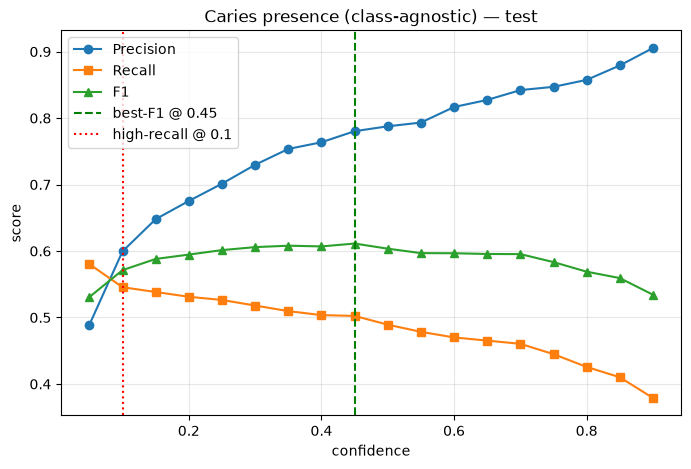

best-F1:      P=78.0 R=50.2 F1=61.1 @conf=0.45
high-recall:  P=59.9 R=54.6 @conf=0.1


In [15]:
def iou_matrix(a, b):
    if len(a) == 0 or len(b) == 0: return np.zeros((len(a), len(b)))
    ix1 = np.maximum(a[:,None,0], b[None,:,0]); iy1 = np.maximum(a[:,None,1], b[None,:,1])
    ix2 = np.minimum(a[:,None,2], b[None,:,2]); iy2 = np.minimum(a[:,None,3], b[None,:,3])
    iw = np.clip(ix2-ix1, 0, None); ih = np.clip(iy2-iy1, 0, None); inter = iw*ih
    aa = (a[:,2]-a[:,0])*(a[:,3]-a[:,1]); ab = (b[:,2]-b[:,0])*(b[:,3]-b[:,1])
    return inter / (aa[:,None] + ab[None,:] - inter + 1e-9)

def pr_at(conf, iou_thr=0.5):
    tp = fp = fn = 0
    for pb, pc, gt in presence_records:
        keep = pc >= conf
        pbb = pb[keep]; order = np.argsort(-pc[keep]); pbb = pbb[order]
        if len(gt) == 0: fp += len(pbb); continue
        if len(pbb) == 0: fn += len(gt); continue
        ious = iou_matrix(pbb, gt); matched = np.zeros(len(gt), bool)
        for i in range(len(pbb)):
            j = int(np.argmax(ious[i]))
            if ious[i, j] >= iou_thr and not matched[j]: matched[j] = True; tp += 1
            else: fp += 1
        fn += int(np.sum(~matched))
    prec = tp/(tp+fp+1e-9); rec = tp/(tp+fn+1e-9); f1 = 2*prec*rec/(prec+rec+1e-9)
    return dict(conf=round(float(conf),2), tp=tp, fp=fp, fn=fn,
               precision=float(prec), recall=float(rec), f1=float(f1))

sweep = [pr_at(c) for c in np.round(np.arange(0.05, 0.91, 0.05), 2)]
best_f1 = max(sweep, key=lambda d: d["f1"])
hi = [d for d in sweep if d["precision"] >= 0.50]
high_recall = max(hi, key=lambda d: d["recall"]) if hi else max(sweep, key=lambda d: d["recall"])
presence = {"sweep": sweep, "best_f1_point": best_f1, "high_recall_point": high_recall}
with open(os.path.join(WORK, "caries_presence.json"), "w") as f:
    json.dump(presence, f, indent=2)

cs = [d["conf"] for d in sweep]
plt.figure(figsize=(8,5))
plt.plot(cs, [d["precision"] for d in sweep], "o-", label="Precision")
plt.plot(cs, [d["recall"] for d in sweep], "s-", label="Recall")
plt.plot(cs, [d["f1"] for d in sweep], "^-", label="F1")
plt.axvline(best_f1["conf"], color="g", ls="--", label=f"best-F1 @ {best_f1['conf']}")
plt.axvline(high_recall["conf"], color="r", ls=":", label=f"high-recall @ {high_recall['conf']}")
plt.xlabel("confidence"); plt.ylabel("score"); plt.title("Caries presence (class-agnostic) — test")
plt.legend(); plt.grid(alpha=0.3)
os.makedirs(os.path.join(WORK, "plots"), exist_ok=True)
plt.savefig(os.path.join(WORK, "plots", "caries_presence_pr.png"), dpi=120, bbox_inches="tight"); plt.show()
print(f"best-F1:      P={best_f1['precision']*100:.1f} R={best_f1['recall']*100:.1f} F1={best_f1['f1']*100:.1f} @conf={best_f1['conf']}")
print(f"high-recall:  P={high_recall['precision']*100:.1f} R={high_recall['recall']*100:.1f} @conf={high_recall['conf']}")

## 10 · Save annotated test predictions

Predictions are saved at the **best-F1 presence confidence** — annotated images plus a JSON of
per-image detections (boxes, classes, confidences), so you have the raw test results on disk.

In [17]:
PRED_CONF = presence["best_f1_point"]["conf"]
# PRED_CONF = 0.1
pred_dir = os.path.join(WORK, "predictions_test"); os.makedirs(pred_dir, exist_ok=True)
box_ann = sv.BoxAnnotator(thickness=2)
lab_ann = sv.LabelAnnotator(text_scale=0.5)

pred_dump = {}
for path, _, _ in tqdm(test_ds, desc="save predictions"):
    image = Image.open(path).convert("RGB")
    det = best.predict(image, threshold=PRED_CONF)
    labels = [f"{test_ds.classes[c]} {s:.2f}" for c, s in zip(det.class_id, det.confidence)]
    out = box_ann.annotate(image.copy(), det)
    out = lab_ann.annotate(out, det, labels)
    name = os.path.basename(path)
    out.save(os.path.join(pred_dir, name))
    pred_dump[name] = [{"class": test_ds.classes[int(c)], "conf": float(s),
                        "xyxy": [float(v) for v in b]}
                       for b, c, s in zip(det.xyxy, det.class_id, det.confidence)]
json.dump(pred_dump, open(os.path.join(pred_dir, "_predictions.json"), "w"), indent=2)
print("Saved annotated test predictions ->", pred_dir, f"(conf={PRED_CONF})")

save predictions:   0%|          | 0/320 [00:00<?, ?it/s]

Saved annotated test predictions -> /caries_run/predictions_test (conf=0.45)


## 11 · Training graphs + qualitative check

In [18]:
# RF-DETR writes a metrics plot + (often) a results log into the output dir.
shown = False
for p in [os.path.join(rfdetr_out, "metrics_plot.png"),
          os.path.join(rfdetr_out, "results.png")]:
    if os.path.exists(p):
        plt.figure(figsize=(11, 6)); plt.imshow(plt.imread(p)); plt.axis("off")
        plt.title(os.path.basename(p)); plt.show(); shown = True

# Try to plot the training log if present (json/csv vary by version).
log_json = os.path.join(rfdetr_out, "log.txt")
if os.path.exists(log_json):
    try:
        rows = [json.loads(l) for l in open(log_json) if l.strip()]
        ep = [r.get("epoch", i) for i, r in enumerate(rows)]
        plt.figure(figsize=(11,5))
        for key in ["train_loss", "test_coco_eval_bbox"]:
            if key == "test_coco_eval_bbox":
                m50 = [r[key][1] if isinstance(r.get(key), list) and len(r[key])>1 else np.nan for r in rows]
                plt.plot(ep, m50, label="mAP50 (val)")
            elif any(key in r for r in rows):
                plt.plot(ep, [r.get(key, np.nan) for r in rows], label=key)
        plt.xlabel("epoch"); plt.grid(alpha=0.3); plt.legend(); plt.title("RF-DETR training")
        plt.savefig(os.path.join(WORK, "plots", "training_curve.png"), dpi=120, bbox_inches="tight")
        plt.show(); shown = True
    except Exception as e:
        print("[warn] could not parse training log:", e)
if not shown:
    print("No RF-DETR plot artifacts found to display (check", rfdetr_out, ").")

No RF-DETR plot artifacts found to display (check /caries_run/rfdetr_out ).


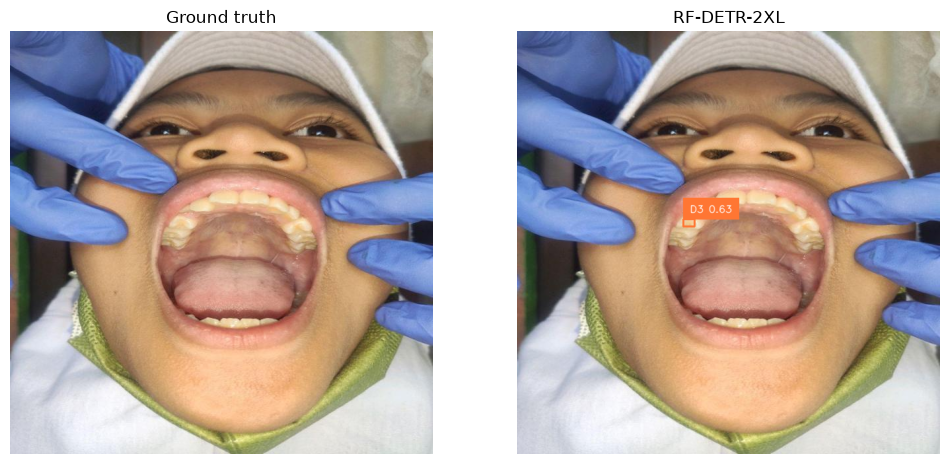

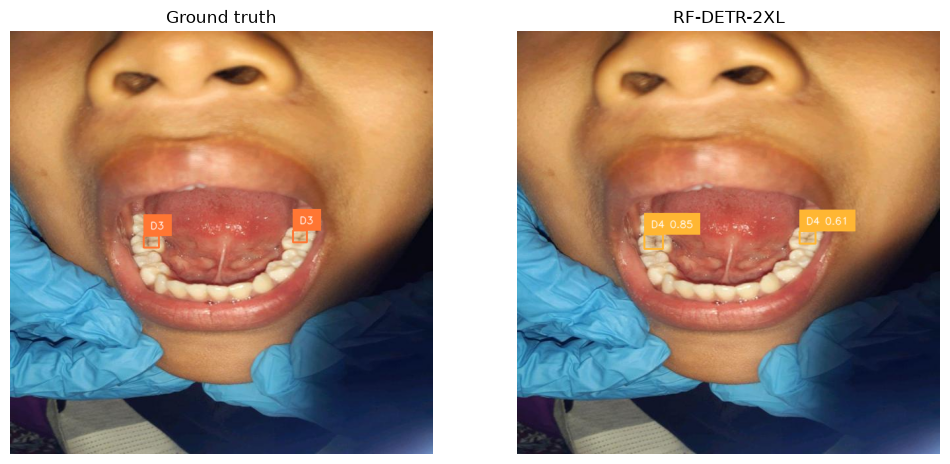

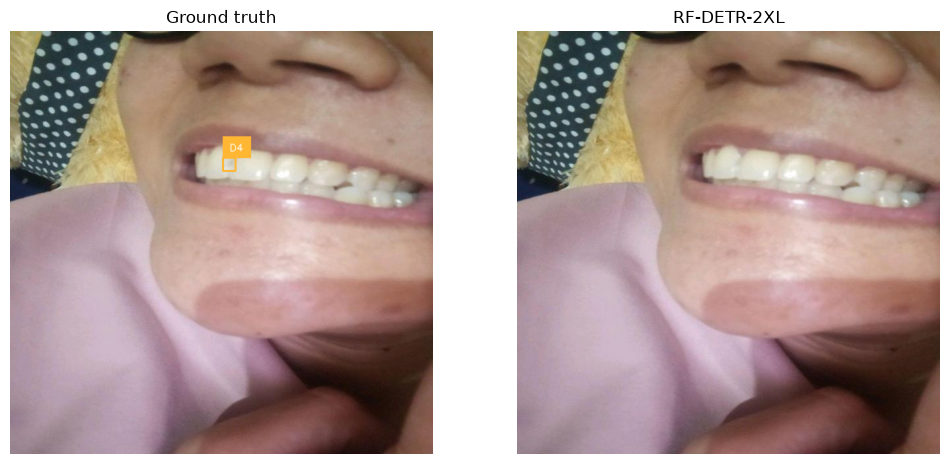

In [19]:
# Qualitative: ground truth vs prediction on a few test images.
for i in range(min(3, len(test_ds))):
    path, _, ann = test_ds[i]
    image = Image.open(path).convert("RGB")
    det = best.predict(image, threshold=PRED_CONF)
    gt = box_ann.annotate(image.copy(), ann)
    gt = lab_ann.annotate(gt, ann, [test_ds.classes[c] for c in ann.class_id])
    pr = box_ann.annotate(image.copy(), det)
    pr = lab_ann.annotate(pr, det, [f"{test_ds.classes[c]} {s:.2f}"
                                    for c, s in zip(det.class_id, det.confidence)])
    sv.plot_images_grid([gt, pr], grid_size=(1,2), titles=["Ground truth", "RF-DETR-2XL"])

## 12 · Save the model + a results summary

In [20]:
shutil.copy2(BEST_CKPT, os.path.join(WORK, "best.pth"))
summary = {"model": "RFDETR2XLarge", "resolution": RFDETR_RESOLUTION, "epochs": RFDETR_EPOCHS,
           "batch": RFDETR_BATCH, "grad_accum": RFDETR_GRAD_ACCUM, "lr": RFDETR_LR,
           "test_metrics": test_metrics,
           "caries_presence": {"best_f1": presence["best_f1_point"],
                               "high_recall": presence["high_recall_point"]},
           "artifacts": {"weights": os.path.join(WORK, "best.pth"),
                         "test_metrics": os.path.join(WORK, "test_metrics.json"),
                         "caries_presence": os.path.join(WORK, "caries_presence.json"),
                         "predictions": os.path.join(WORK, "predictions_test"),
                         "plots": os.path.join(WORK, "plots"),
                         "run_dir": rfdetr_out}}
with open(os.path.join(WORK, "summary.json"), "w") as f:
    json.dump(summary, f, indent=2)
print(json.dumps(summary["test_metrics"], indent=2))
print(json.dumps(summary["caries_presence"], indent=2))
print("\nAll artifacts under:", WORK)
for p in sorted(glob.glob(os.path.join(WORK, "*"))):
    print("  ", os.path.basename(p))

{
  "weights": "/caries_run/rfdetr_out/checkpoint_best_total.pth",
  "model": "RFDETR2XLarge",
  "resolution": 880,
  "map50": 0.44821181893348694,
  "map50_95": 0.2964733839035034,
  "per_class": {
    "D1": {
      "AP50-95": 0.22031119465827942,
      "AP50": 0.30077803134918213
    },
    "D2": {
      "AP50-95": 0.26875537633895874,
      "AP50": 0.3580409586429596
    },
    "D3": {
      "AP50-95": 0.3014754056930542,
      "AP50": 0.41125360131263733
    },
    "D4": {
      "AP50-95": 0.26730725169181824,
      "AP50": 0.42882421612739563
    },
    "D5": {
      "AP50-95": 0.29802101850509644,
      "AP50": 0.4739968478679657
    },
    "D6": {
      "AP50-95": 0.4229700565338135,
      "AP50": 0.7163771986961365
    }
  }
}
{
  "best_f1": {
    "conf": 0.45,
    "tp": 419,
    "fp": 118,
    "fn": 415,
    "precision": 0.7802607076335564,
    "recall": 0.5023980815341698,
    "f1": 0.6112326764007637
  },
  "high_recall": {
    "conf": 0.1,
    "tp": 455,
    "fp": 304,
    

## 13 · Notes & the "more mAP" levers

**Implemented (following RF-DETR's documented defaults):**
1. **Largest RF-DETR** — RFDETR-2XL (DINOv2 backbone, ~127M params), fine-tuned from its
   COCO-pretrained checkpoint. ✅
2. **Defaults** — `resolution=880` (2XL native), `epochs=100`, `lr=1e-4`, total batch 16. ✅
3. **`optimize_for_inference()`** — fused/compiled model for fast, low-memory eval. ✅
4. **Confidence tuning** — the caries-presence sweep gives best-F1 and high-recall operating points. ✅
5. **Background images kept** — D0-only images become background negatives (suppress false positives). ✅
6. **No TTA** — RF-DETR has no built-in test-time augmentation and the docs don't use it. ✅

**Push higher if needed:** train longer than 100 epochs (small datasets can benefit), or tune the
deployment confidence toward recall via the caries-presence operating points above.

**Honest caveats:** RF-DETR-XL/2XL weights are **PML 1.0** (not Apache) — check the license for your
use. The dataset mixes clinical close-ups with casual phone selfies (tiny, near-invisible lesions),
which caps accuracy. The old 52.3% mAP baseline used D0 + a different class set, so it is a rough
reference, not an apples-to-apples comparison.